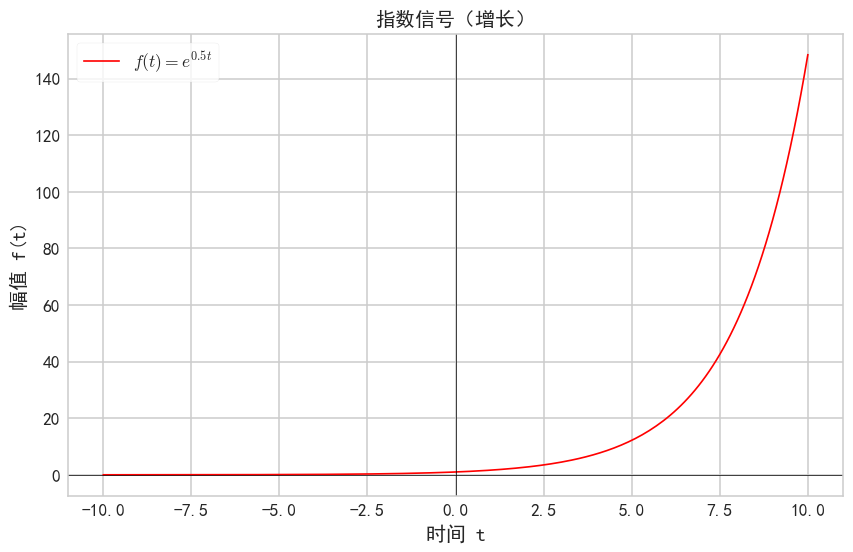

In [72]:
import numpy as np
import matplotlib.pyplot as plt

from jupyterthemes import jtplot
jtplot.style()

# 设置全局字体为 SimHei（黑体）
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题


def f1_std(t):
    return np.exp(0.5 * t)

t_start = -10
t_end = 10
step = 0.1
t = np.arange(t_start, t_end + step, step)
y = f1_std(t)

plt.figure(figsize=(10, 6))
plt.plot(t, y, label=r'$f(t) = e^{0.5t}$', color='red')
plt.title('指数信号（增长）')
plt.xlabel('时间 t')
plt.ylabel('幅值 f(t)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

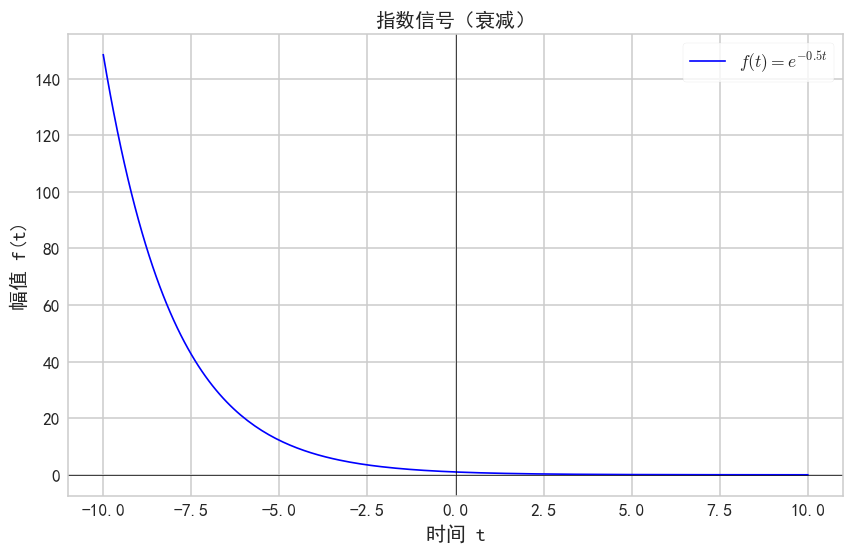

In [73]:
import numpy as np
import matplotlib.pyplot as plt

def f2_std(t):
    return np.exp(-0.5 * t)

t_start = -10
t_end = 10
step = 0.1
t = np.arange(t_start, t_end + step, step)
y = f2_std(t)

plt.figure(figsize=(10, 6))
plt.plot(t, y, label=r'$f(t) = e^{-0.5t}$', color='blue')
plt.title('指数信号（衰减）')
plt.xlabel('时间 t')
plt.ylabel('幅值 f(t)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

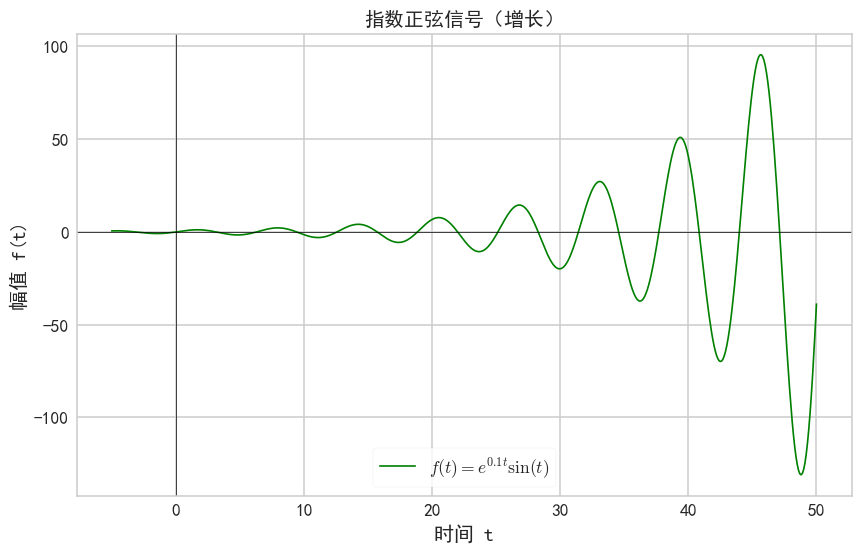

In [74]:
import numpy as np
import matplotlib.pyplot as plt

def f3_std(t):
    return np.exp(0.1 * t) * np.sin(t)

t_start = -5
t_end = 50
step = 0.1
t = np.arange(t_start, t_end + step, step)
y = f3_std(t)

plt.figure(figsize=(10, 6))
plt.plot(t, y, label=r'$f(t) = e^{0.1t}\sin(t)$', color='green')
plt.title('指数正弦信号（增长）')
plt.xlabel('时间 t')
plt.ylabel('幅值 f(t)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

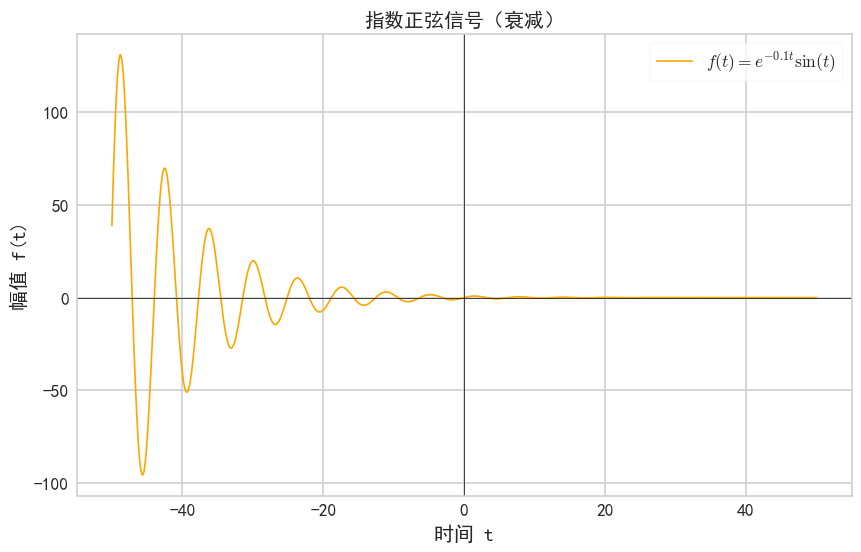

In [75]:
import numpy as np
import matplotlib.pyplot as plt

def f4_std(t):
    return np.exp(-0.1 * t) * np.sin(t)

t_start = -50
t_end = 50
step = 0.1
t = np.arange(t_start, t_end + step, step)
y = f4_std(t)

plt.figure(figsize=(10, 6))
plt.plot(t, y, label=r'$f(t) = e^{-0.1t}\sin(t)$', color='orange')
plt.title('指数正弦信号（衰减）')
plt.xlabel('时间 t')
plt.ylabel('幅值 f(t)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

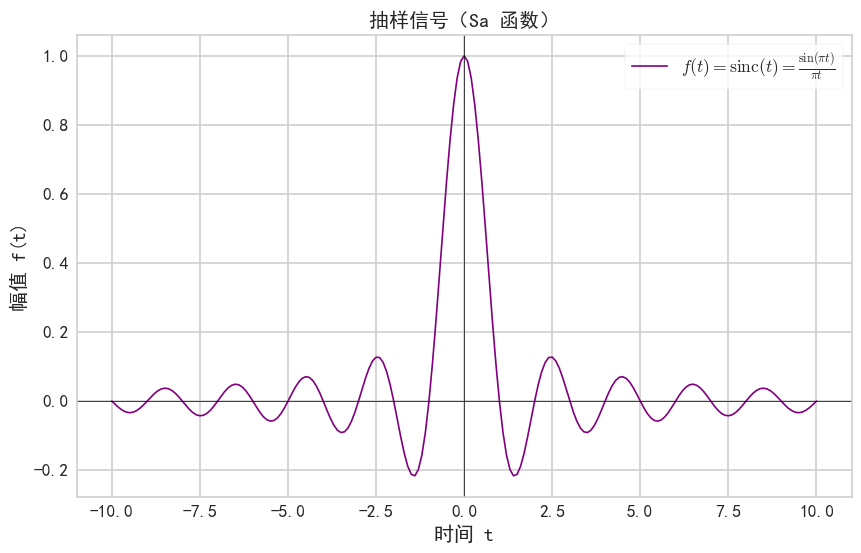

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def f5_std(t):
    # np.sinc(t) = sin(pi*t) / (pi*t)
    return np.sinc(t)

t_start = -10
t_end = 10
step = 0.1
t = np.arange(t_start, t_end + step, step)
y = f5_std(t)

plt.figure(figsize=(10, 6))
plt.plot(t, y, label=r'$f(t) = \text{sinc}(t) = \frac{\sin(\pi t)}{\pi t}$', color='purple')
plt.title('抽样信号（Sa 函数）')
plt.xlabel('时间 t')
plt.ylabel('幅值 f(t)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

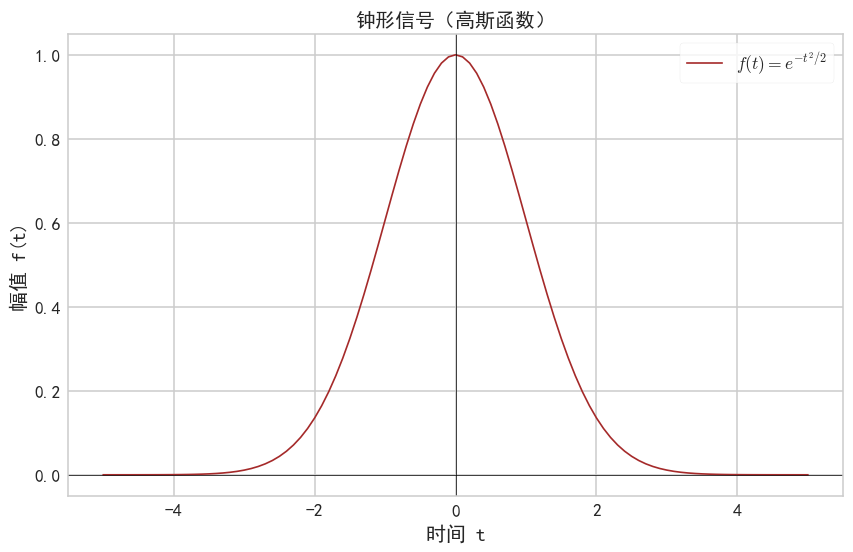

In [78]:
import numpy as np
import matplotlib.pyplot as plt

def f6_std(t):
    return np.exp(-(t**2) / 2)

t_start = -5
t_end = 5
step = 0.1
t = np.arange(t_start, t_end + step, step)
y = f6_std(t)

plt.figure(figsize=(10, 6))
plt.plot(t, y, label=r'$f(t) = e^{-t^2/2}$', color='brown')
plt.title('钟形信号（高斯函数）')
plt.xlabel('时间 t')
plt.ylabel('幅值 f(t)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

In [16]:
import numpy as np
from scipy.optimize import curve_fit
import warnings

# --- 1. 定义我们要拟合的数学模型 ---
# V(t) = K * exp(alpha * t) + V0
def exponential_model(t, K, alpha, V0):
    """
    定义指数模型函数
    t: 时间 (自变量)
    K: 幅度系数
    alpha: 指数增长/衰减率
    V0: 垂直偏移量 (直流偏置)
    """
    return K * np.exp(alpha * t) + V0

# --- 2. 输入所有实验数据 ---
# 将所有时间单位统一为秒(s)，电压单位统一为伏特(V)

# 指数增长信号数据 (合并两组数据以提高拟合精度)
t_growth = np.array([
    # 第 1 组
    -740.0e-6, -360.0e-6, -60.0e-6, 140.0e-6, 280.0e-6,
    # 第 2 组
    500.0e-6, 960.0e-6, 1.38e-3, 1.56e-3, 1.86e-3
])
v_growth = np.array([
    # 第 1 组
    0.320, 0.680, 1.40, 2.24, 3.28,
    # 第 2 组
    0.160, 0.440, 1.04, 1.60, 3.40
])

# 指数衰减信号数据 (合并两组数据)
t_decay = np.array([
    # 第 1 组
    140.0e-6, 240.0e-6, 380.0e-6, 560.0e-6, 1.08e-3,
    # 第 2 组
    1.66e-3, 1.76e-3, 1.84e-3, 2.10e-3, 2.62e-3
])
v_decay = np.array([
    # 第 1 组
    3.64, 2.84, 2.00, 1.28, 0.400,
    # 第 2 组
    4.04, 3.16, 2.60, 1.32, 0.440
])


# --- 3. 进行非线性最小二乘法拟合 ---

# 忽略拟合过程中可能出现的警告
warnings.filterwarnings("ignore")

print("="*50)
print("开始进行数据拟合...")
print("="*50)

# (1) 拟合指数增长信号
# 提供一个合理的初始猜测值 [K, alpha, V0]
# K~1, alpha>0 (增长), V0~0
initial_guess_growth = [1.0, 2500.0, 0.0]
try:
    popt_g, pcov_g = curve_fit(exponential_model, t_growth, v_growth, p0=initial_guess_growth)

    # 提取拟合参数和不确定度 (标准差)
    K_fit_g, alpha_fit_g, V0_fit_g = popt_g
    perr_g = np.sqrt(np.diag(pcov_g))
    K_err_g, alpha_err_g, V0_err_g = perr_g

    print("\n--- 指数增长信号拟合结果 ---")
    print(f"拟合函数: V(t) = K * exp(alpha * t) + V0")
    print("-" * 30)
    print(f"K    = {K_fit_g:.4f} ± {K_err_g:.4f}")
    print(f"alpha= {alpha_fit_g:.4f} ± {alpha_err_g:.4f} (s^-1)")
    print(f"V0   = {V0_fit_g:.4f} ± {V0_err_g:.4f} (V)")
    print("-" * 30)

except RuntimeError:
    print("\n--- 指数增长信号拟合失败 ---")
    print("无法收敛到解，请检查数据或调整初始猜测值。")


# (2) 拟合指数衰减信号
# 提供一个合理的初始猜测值 [K, alpha, V0]
# K~1, alpha<0 (衰减), V0>0 (电压不会低于0)
initial_guess_decay = [4.0, -2500.0, 0.1]
try:
    popt_d, pcov_d = curve_fit(exponential_model, t_decay, v_decay, p0=initial_guess_decay)

    # 提取拟合参数和不确定度 (标准差)
    K_fit_d, alpha_fit_d, V0_fit_d = popt_d
    perr_d = np.sqrt(np.diag(pcov_d))
    K_err_d, alpha_err_d, V0_err_d = perr_d

    print("\n--- 指数衰减信号拟合结果 ---")
    print(f"拟合函数: V(t) = K * exp(alpha * t) + V0")
    print("-" * 30)
    print(f"K    = {K_fit_d:.4f} ± {K_err_d:.4f}")
    print(f"alpha= {alpha_fit_d:.4f} ± {alpha_err_d:.4f} (s^-1)")
    print(f"V0   = {V0_fit_d:.4f} ± {V0_err_d:.4f} (V)")
    print("-" * 30)

except RuntimeError:
    print("\n--- 指数衰减信号拟合失败 ---")
    print("无法收敛到解，请检查数据或调整初始猜测值。")

print("\n" + "="*50)
print("拟合完成。请将以上输出结果复制给我。")
print("="*50)



开始进行数据拟合...

--- 指数增长信号拟合结果 ---
拟合函数: V(t) = K * exp(alpha * t) + V0

拟合参数 (值 ± 标准差):
  K     =   0.0000 ±   0.0001
  alpha =  7115.48 ± 14014.09 (s^-1)
  V0    =   1.2017 ±   0.4049 (V)

--- 指数衰减信号拟合结果 ---
拟合函数: V(t) = K * exp(alpha * t) + V0

拟合参数 (值 ± 标准差):
  K     =   6.4875 ±  17.1158
  alpha = -9124.01 ± 17095.62 (s^-1)
  V0    =   1.8943 ±   0.5012 (V)

拟合完成。请将以上结果复制给我，以便写入报告。
